# 06. RAG 벡터 인덱스 구축 — 혼합 샘플링

Chroma 색인(`chroma_store/`)은 앱의 **게임 분석 탭(리뷰 저장소)** 과 **Q&A 탭(벡터 검색)** 이 함께 쓴다.
학습 데이터는 그대로 두고 색인만 확장하는 **혼합 샘플링**:

1. **train 전체** (5,686건) — 무작위 균형 샘플, 다양한 게임 커버
2. **인기 상위 20개 게임 × 라벨당 최대 200건** (게임당 최대 400건) — 원본 641만 건에서 추가 샘플링,
   train과 동일한 정제(`normalize_text`, min_words=3) 적용 후 병합

`app_name`·`label` 메타데이터 저장. 배포(git 파일당 100MB 제한)를 위해 구축 후 용량을 확인한다.

In [6]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from collections import Counter

import pandas as pd
from datasets import load_dataset
from src.config import DATA_DIR, VECTOR_DIR, OUTPUT_DIR, RANDOM_SEED
from src.data.pipeline import clean_reviews
from src.rag.index import build_index

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_GAMES = 20            # 추가 샘플링할 인기 게임 수
PER_GAME_PER_LABEL = 200  # 게임당 라벨(긍/부정)별 최대 리뷰 수

# ① 학습 train 전체 (이미 정제됨, app_name 포함)
tr = pd.read_csv(DATA_DIR / "train.csv")[["text", "label", "app_name"]]

# ② 원본에서 인기 게임 리뷰 추가 샘플링
ds = load_dataset("ksang/steamreviews", split="train")
counts = Counter(a for a in ds["app_name"] if a)
top_games = {g for g, _ in counts.most_common(TOP_GAMES)}
print("인기 게임:", sorted(top_games))

sub = ds.filter(lambda b: [a in top_games for a in b["app_name"]], batched=True)
pop = sub.to_pandas()[["app_name", "review_text", "review_score"]]
pop = (pop.groupby(["app_name", "review_score"], group_keys=False)
          .apply(lambda g: g.sample(min(len(g), PER_GAME_PER_LABEL),
                                    random_state=RANDOM_SEED)))
extra = clean_reviews(pop, "review_text", "review_score",
                      normalize=True, min_words=3, extra_cols=["app_name"])

# ③ 병합 (중복 리뷰 제거)
df = (pd.concat([tr, extra])
        .drop_duplicates(subset=["text"]).reset_index(drop=True))
df["app_name"] = df["app_name"].fillna("(unknown)")
print(f"train {len(tr)} + 인기 게임 {len(extra)} → 색인 대상 {len(df):,}건")

Repo card metadata block was not found. Setting CardData to empty.


인기 게임: ['Arma 3', 'BioShock Infinite', 'DayZ', 'Dota 2', 'Fallout: New Vegas', 'Grand Theft Auto V', 'Heroes & Generals', 'Left 4 Dead 2', 'PAYDAY 2', 'Portal 2', 'Robocraft', 'Rocket League', 'Rust', 'Space Engineers', 'Starbound', 'Terraria', 'The Forest', 'The Witcher 3: Wild Hunt', 'Undertale', 'Warframe']
train 5686 + 인기 게임 5146 → 색인 대상 10,810건


/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_79423/1601119153.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), PER_GAME_PER_LABEL),


In [8]:
# 이 노트북과 앱이 사용하는 src 모듈 소스 (실행되는 원본을 그대로 표시 — 복사본 아님)
import inspect
from src.rag import index, qa
from src.llm import client, summarize
for mod in (index, qa, client, summarize):
    print(f"{'=' * 30} {mod.__name__} {'=' * 30}")
    print(inspect.getsource(mod))

# 앱 진입점 (streamlit 실행 파일이라 import 대신 파일로 읽어 표시)
print(f"{'=' * 30} app.py {'=' * 30}")
print((ROOT / "app.py").read_text())

============================== src.rag.index ==============================
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

from src.config import EMBED_MODEL_ID

_embeddings = None


def get_embeddings():
    """임베딩 모델 (최초 1회만 로드)."""
    global _embeddings
    if _embeddings is None:
        _embeddings = HuggingFaceEmbeddings(model_name=EMBED_MODEL_ID)
    return _embeddings


def get_vectorstore(persist_dir):
    """디스크에 영속화된 Chroma 벡터스토어."""
    return Chroma(collection_name="reviews",
                  persist_directory=str(persist_dir),
                  embedding_function=get_embeddings())


def build_index(texts, persist_dir, metadatas=None, batch_size=2000):
    vs = get_vectorstore(persist_dir)
    vs.reset_collection()  # 재구축 시 기존 색인 비우고 새로 시작
    texts = list(texts)
    # Chroma의 1회 add 배치 상한을 넘지 않도록 나눠서 추가
    for s in range(0, len(texts), batch_size):
        e = s + batch_size
        vs.add_texts(texts[s:e],
                

In [3]:
# 색인 구축 + 용량 확인 (git 파일당 100MB 제한)
metadatas = [{"app_name": str(a), "label": int(l)}
             for a, l in zip(df["app_name"], df["label"])]
build_index(df["text"].tolist(), VECTOR_DIR, metadatas=metadatas)
print(f"indexed {len(df):,} reviews into {VECTOR_DIR}")

biggest = max(VECTOR_DIR.rglob("*"), key=lambda p: p.stat().st_size if p.is_file() else 0)
total_mb = sum(p.stat().st_size for p in VECTOR_DIR.rglob("*") if p.is_file()) / 1e6
big_mb = biggest.stat().st_size / 1e6
print(f"총 용량 {total_mb:.0f}MB / 최대 파일 {biggest.name} {big_mb:.0f}MB")
assert big_mb < 95, "git 100MB 제한 초과 위험 — PER_GAME_PER_LABEL을 줄이세요"

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7709.02it/s]


indexed 10,810 reviews into /Users/gomuseo/Desktop/Python/review-check/chroma_store
총 용량 106MB / 최대 파일 chroma.sqlite3 48MB


In [ ]:
# 검색 스모크 테스트 (LangChain 벡터스토어)
from src.rag.index import get_collection
col = get_collection(VECTOR_DIR)
for doc in col.similarity_search("is this game fun?", k=3):
    print("-", doc.page_content[:100])

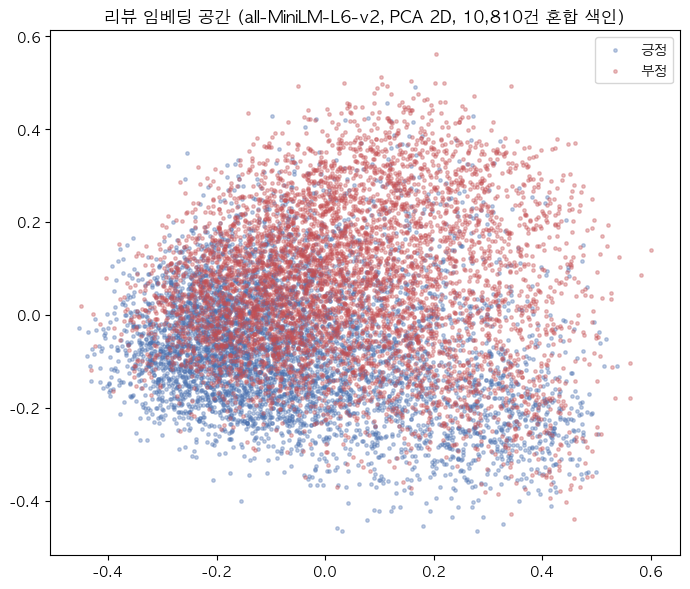

In [5]:
# 임베딩 공간 시각화: PCA 2D, 리뷰 감성 라벨로 색상 구분
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

got = col.get(include=["embeddings", "metadatas"])
order = np.argsort([int(i) for i in got["ids"]])
embs = np.array(got["embeddings"])[order]
labels = np.array([m["label"] for m in got["metadatas"]])[order]

pts = PCA(n_components=2, random_state=42).fit_transform(embs)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, name, color in [(1, "긍정", "#4c72b0"), (0, "부정", "#c44e52")]:
    m = labels == lab
    ax.scatter(pts[m, 0], pts[m, 1], s=6, alpha=0.35, label=name, color=color)
ax.set_title(f"리뷰 임베딩 공간 (all-MiniLM-L6-v2, PCA 2D, {len(labels):,}건 혼합 색인)")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_embedding_pca_v3.png", dpi=150, bbox_inches="tight")
plt.show()